## 绘图-新

In [31]:
import numpy as np

def analyze_od_matrix(file_path):
    """
    分析OD矩阵中的零值和非零值统计信息
    
    参数:
    file_path (str): OD矩阵数据文件路径
    
    返回:
    dict: 包含统计结果的字典
    """
    try:
        # 加载OD矩阵数据
        real_values = np.load(file_path)
        
        # 计算零值和非零值的数量
        zero_count = np.count_nonzero(real_values == 0)
        non_zero_count = np.count_nonzero(real_values)
        
        # 计算非零值的比重
        total_values = real_values.size
        non_zero_ratio = non_zero_count / total_values
        
        # 构建结果字典
        result = {
            'zero_count': zero_count,
            'non_zero_count': non_zero_count,
            'total_values': total_values,
            'non_zero_ratio': non_zero_ratio
        }
        
        return result
    
    except FileNotFoundError:
        print(f"错误: 文件 '{file_path}' 未找到")
        return None
    except Exception as e:
        print(f"错误: 发生未知错误 - {e}")
        return None

if __name__ == "__main__":
    # 指定OD矩阵文件路径
    file_path = './可视化/测试集TNN/真实值.npy'
    
    # 分析OD矩阵
    result = analyze_od_matrix(file_path)
    
    # 打印结果
    if result:
        print(f"OD矩阵形状: {np.load(file_path).shape}")
        print(f"零值数量: {result['zero_count']}")
        print(f"非零值数量: {result['non_zero_count']}")
        print(f"总值数量: {result['total_values']}")
        print(f"非零值比例: {result['non_zero_ratio']:.4f} ({result['non_zero_ratio']*100:.2f}%)")    

OD矩阵形状: (35, 110, 110)
零值数量: 371777
非零值数量: 51723
总值数量: 423500
非零值比例: 0.1221 (12.21%)


Max OD timestep: 20


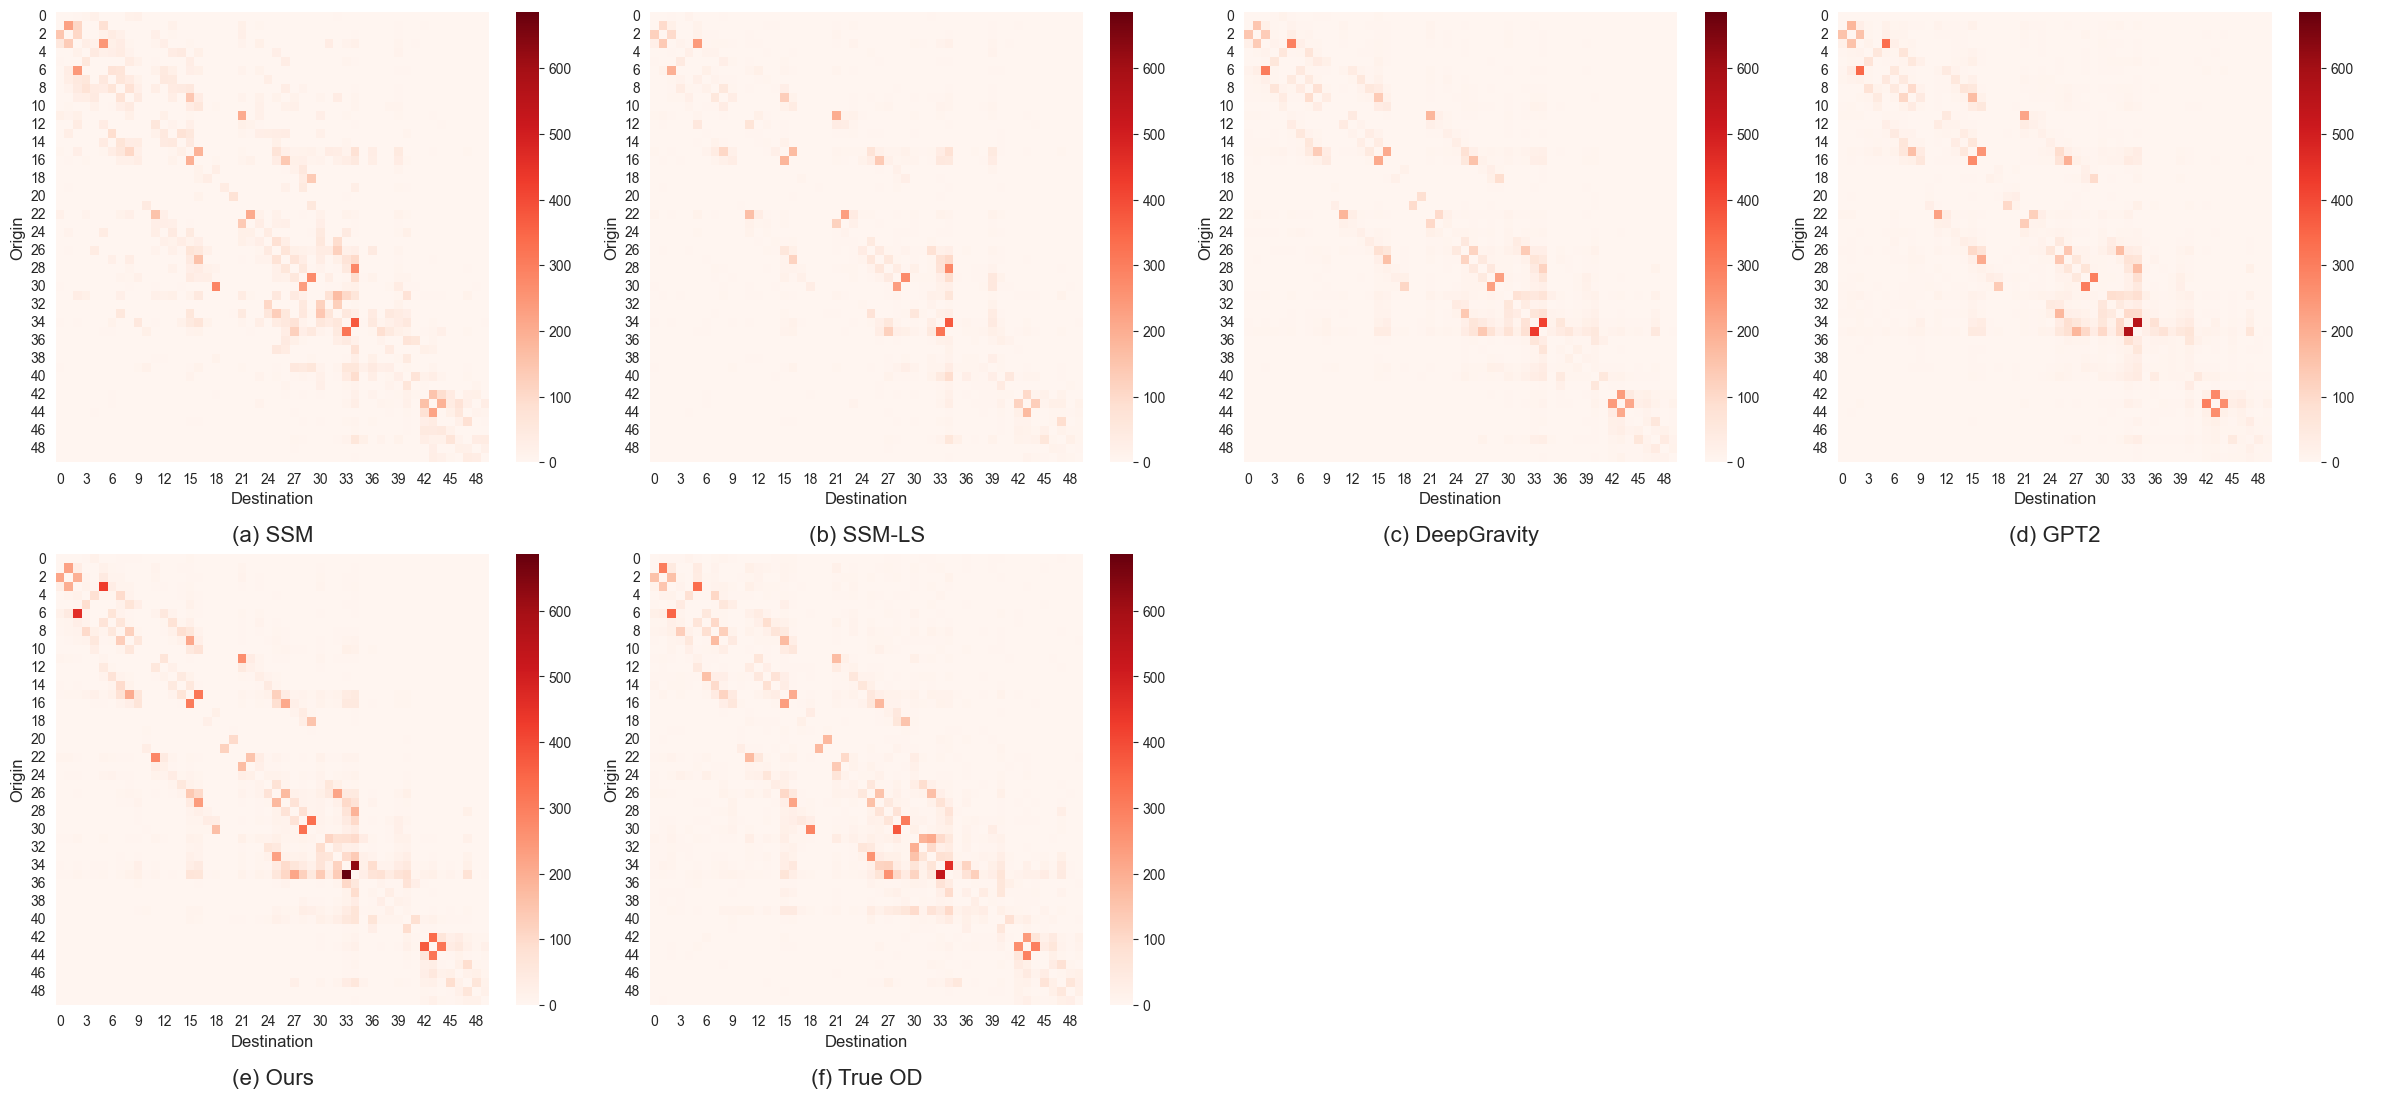

In [16]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from datetime import datetime

# 获取当前时间
now = datetime.now()

# 按所需格式转换为字符串
formatted_time = now.strftime("%Y-%m-%d-%H-%M-%S") 

def load_predictions():
    """加载所有预测数据，并确保'Ours'排在最后"""
    methods = {
        "SSM": "./可视化/测试集TNN/Pred_SSM_SUE_MSA_6.15_7.80.npy",
        "SSM-LS": "./可视化/测试集TNN/Pred_SSM_LS_SUE_MSA_6.15_9.4040.npy",
        "DeepGravity": "./可视化/测试集TNN/Pred_DeepGravity_6.88.npy",
        "GPT2": "./可视化/测试集TNN/Pred_GPT2.npy",
        
        "Ours": "./可视化/测试集TNN/Pred_ours_ZINB.npy"
    }
    predictions = {}
    for name, path in methods.items():
        if os.path.exists(path):
            predictions[name] = np.load(path)
        else:
            print(f"警告：找不到文件 {path}，跳过该方法。")

    # 确保 Ours 始终在最后
    sorted_predictions = {}
    for key in predictions:
        if key != "Ours":
            sorted_predictions[key] = predictions[key]
    if "Ours" in predictions:
        sorted_predictions["Ours"] = predictions["Ours"]

    return sorted_predictions


def load_real_data():
    try:
        return np.load('./可视化/测试集TNN/真实值.npy')
    except FileNotFoundError:
        print("真实值文件未找到，请检查路径。")
        return None

def plot_heatmaps(predictions_dict, real_od_t, fontsize=16):
    method_names = list(predictions_dict.keys())

    # 查找真实值总和最大的时间步
    od_sums = np.sum(real_od_t, axis=(1, 2))
    t_max = np.argmax(od_sums)
    t_max = 20
    print(f"Max OD timestep: {t_max}")

    # 取该时间步的真实 OD 和预测 OD
    all_real_od = real_od_t[t_max]
    all_pred_od_list = [pred[t_max] for pred in predictions_dict.values()]

    vmin = 0
    vmax = max([pred.max() for pred in all_pred_od_list] + [all_real_od.max()])

    # 子图数量和布局
    total_plots = len(all_pred_od_list) + 1  # 包括真实 OD
    rows = (total_plots + 3) // 4
    cols = min(4, total_plots)

    # 创建子图
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5.5 * rows))
    axes = axes.flatten()
    color = "Reds" # coolwarm Blues
    # 绘制预测图（在前面）
    for i, (name, pred_od) in enumerate(zip(method_names, all_pred_od_list)):
        ax = axes[i]
        sns.heatmap(pred_od, cmap=color, cbar=True, vmin=vmin, vmax=vmax, ax=ax)
        ax.set_xlabel("Destination", fontsize=12)
        ax.set_ylabel("Origin", fontsize=12)
        ax.text(0.5, -0.14, f"({chr(97 + i)}) {name}", transform=ax.transAxes,
                ha='center', va='top', fontsize=fontsize)

    # 绘制真实 OD 图（在最后）
    ax_real = axes[len(all_pred_od_list)]
    sns.heatmap(all_real_od, cmap=color, cbar=True, vmin=vmin, vmax=vmax, ax=ax_real)
    ax_real.set_xlabel("Destination", fontsize=12)
    ax_real.set_ylabel("Origin", fontsize=12)
    ax_real.text(0.5, -0.14, f"({chr(97 + len(all_pred_od_list))}) True OD", transform=ax_real.transAxes,
                 ha='center', va='top', fontsize=fontsize)

    # 隐藏多余子图
    for i in range(total_plots, len(axes)):
        axes[i].axis('off')

    plt.tight_layout()
    # plt.savefig("./可视化/结果图/ODE_1-{formatted_time}.png")
    fig.savefig(f'./可视化/结果图/ODE_1-{formatted_time}.png', format='png', dpi=300, bbox_inches='tight')


# def plot_heatmaps(predictions_dict, real_od_t):
#     method_names = list(predictions_dict.keys())
#     all_pred_od_list = [np.mean(predictions_dict[name], axis=0) for name in method_names]
#     all_real_od = np.mean(real_od_t, axis=0)
# 
#     vmin = min([pred.min() for pred in all_pred_od_list] + [all_real_od.min()])
#     vmax = max([pred.max() for pred in all_pred_od_list] + [all_real_od.max()])
# 
#     fig, axes = plt.subplots(1, len(all_pred_od_list) + 1, figsize=(6 * (len(all_pred_od_list) + 1), 6))
#     sns.heatmap(all_real_od, cmap="Blues", cbar=True, vmin=vmin, vmax=vmax, ax=axes[0])
#     axes[0].set_title("Average True OD Matrix", fontsize=18)
# 
#     for i, (name, pred_od) in enumerate(zip(method_names, all_pred_od_list)):
#         sns.heatmap(pred_od, cmap="Blues", cbar=True, vmin=vmin, vmax=vmax, ax=axes[i + 1])
#         axes[i + 1].set_title(f"Predicted ({name})", fontsize=18)
# 
#     plt.tight_layout()
#     plt.savefig("./可视化/结果图/ODE_1-{formatted_time}.png")

def plot_heatmaps_sub(predictions_dict, real_od_t, fontsize=16):
    method_names = list(predictions_dict.keys())

    # 查找真实值总和最大的时间步
    od_sums = np.sum(real_od_t, axis=(1, 2))
    t_max = np.argmax(od_sums)
    t_max = 20
    print(f"Max OD timestep: {t_max}")

    # 取该时间步的真实 OD 和预测 OD
    all_real_od = real_od_t[t_max]
    all_pred_od_list = [pred[t_max] for pred in predictions_dict.values()]

    # ==== 新增：选取显著的 80x80 子网格 ====
    # 以真实OD为基准，找到行和列的重要度（流量和）
    row_sum = np.sum(all_real_od, axis=1)
    col_sum = np.sum(all_real_od, axis=0)

    # 找到流量和最大的前 80 个行和列索引
    top_rows = np.argsort(row_sum)[-50:]
    top_cols = np.argsort(col_sum)[-50:]

    # 排序保证热力图更可读（可选）
    top_rows = np.sort(top_rows)
    top_cols = np.sort(top_cols)

    # 根据选中的行列索引裁剪所有 OD
    all_real_od_sub = all_real_od[np.ix_(top_rows, top_cols)]
    all_pred_od_list_sub = [
        pred_od[np.ix_(top_rows, top_cols)] for pred_od in all_pred_od_list
    ]

    vmin = 0
    vmax = max([pred.max() for pred in all_pred_od_list_sub] + [all_real_od_sub.max()])

    # 子图数量和布局
    total_plots = len(all_pred_od_list_sub) + 1  # 包括真实 OD
    rows = (total_plots + 3) // 4
    cols = min(4, total_plots)

    # 创建子图
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5.5 * rows))
    axes = axes.flatten()
    color = "Reds"  # 可以换成 "coolwarm" 等

    # 绘制预测热力图
    for i, (name, pred_od) in enumerate(zip(method_names, all_pred_od_list_sub)):
        ax = axes[i]
        sns.heatmap(pred_od, cmap=color, cbar=True, vmin=vmin, vmax=vmax, ax=ax)
        ax.set_xlabel("Destination", fontsize=12)
        ax.set_ylabel("Origin", fontsize=12)
        ax.text(0.5, -0.14, f"({chr(97 + i)}) {name}", transform=ax.transAxes,
                ha='center', va='top', fontsize=fontsize)

    # 绘制真实 OD 热力图
    ax_real = axes[len(all_pred_od_list_sub)]
    sns.heatmap(all_real_od_sub, cmap=color, cbar=True, vmin=vmin, vmax=vmax, ax=ax_real)
    ax_real.set_xlabel("Destination", fontsize=12)
    ax_real.set_ylabel("Origin", fontsize=12)
    ax_real.text(0.5, -0.14, f"({chr(97 + len(all_pred_od_list_sub))}) True OD", transform=ax_real.transAxes,
                 ha='center', va='top', fontsize=fontsize)

    # 隐藏多余子图
    for i in range(total_plots, len(axes)):
        axes[i].axis('off')

    plt.tight_layout()
    fig.savefig(f'./可视化/结果图/ODE_2-{formatted_time}.png', format='png', dpi=300, bbox_inches='tight')
    
    
def plot_scatter(predictions_dict, real_od_t, fontsize=16):
    method_names = list(predictions_dict.keys())
    all_real_flat = real_od_t.flatten()
    all_pred_flat_list = [pred.flatten() for pred in predictions_dict.values()]
    max_val = max(np.max(all_real_flat), *[np.max(pred) for pred in all_pred_flat_list])
    lims = [0, max_val]

    # 计算子图的行列数，每行显示2个子图
    total_plots = len(all_pred_flat_list)
    rows = (total_plots + 1) // 3
    cols = min(3, total_plots)

    # 创建子图
    fig, axes = plt.subplots(rows, cols, figsize=(8 * cols, 8 * rows))
    if rows == 1 and cols == 1:
        axes = np.array([axes])
    else:
        axes = axes.flatten()

    # 设置颜色列表
    base_colors = ['red', 'blue', 'green', 'purple', 'orange', 'brown']

    for i, (ax, name, pred_flat) in enumerate(zip(axes, method_names, all_pred_flat_list)):
        # 特殊处理 'ours' 方法为黑色
        color = 'black' if 'ours' in name.lower() else base_colors[i % len(base_colors)]
        ax.scatter(all_real_flat, pred_flat, alpha=1, color=color)
        ax.plot(lims, lims, color=color, linestyle='-', linewidth=2)
        ax.set_xlim(lims)
        ax.set_ylim(lims)
        ax.set_xlabel("True OD", fontsize=12)
        ax.set_ylabel("Predicted OD", fontsize=12)
        ax.text(0.5, -0.08, f"({chr(97 + i)}) {name}", transform=ax.transAxes,
                ha='center', va='top', fontsize=fontsize)

        # 去除背景色、网格，并加边框
        ax.set_facecolor('white')
        ax.grid(False)
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor('black')
            spine.set_linewidth(1.5)
        ax.tick_params(colors='black')

    # 隐藏多余子图
    for i in range(total_plots, len(axes)):
        axes[i].axis('off')


    plt.tight_layout()
    # 设置子图间距
    # plt.subplots_adjust(hspace=0.3)  # 设置行间距，数值可调

    fig.savefig(f'./可视化/结果图/ODE_4-{formatted_time}.png', format='png', dpi=300, bbox_inches='tight')
    # fig.savefig(f'./可视化/结果图/ODE_4.pdf', format='pdf', dpi=300, bbox_inches='tight')
    
# # *绘制散点+拟合线*
# import numpy as np
# import matplotlib.pyplot as plt
# 
# def plot_scatter(predictions_dict, real_od_t):
#     method_names = list(predictions_dict.keys())
#     all_real_flat = real_od_t.flatten()
#     all_pred_flat_list = [pred.flatten() for pred in predictions_dict.values()]
#     max_val = max(np.max(all_real_flat), *[np.max(pred) for pred in all_pred_flat_list])
#     lims = [0, max_val]
# 
#     fig, axes = plt.subplots(1, len(all_pred_flat_list), figsize=(8 * len(all_pred_flat_list), 8))
#     if len(all_pred_flat_list) == 1:
#         axes = [axes]
# 
#     for ax, name, pred_flat in zip(axes, method_names, all_pred_flat_list):
#         ax.scatter(all_real_flat, pred_flat, alpha=0.5)
#         ax.plot(lims, lims, 'r-', linewidth=2)
# 
#         # 计算拟合线
#         coefficients = np.polyfit(all_real_flat, pred_flat, 1)  # 一次多项式拟合（直线）
#         poly = np.poly1d(coefficients)
#         x_fit = np.linspace(lims[0], lims[1], 100)
#         y_fit = poly(x_fit)
#         ax.plot(x_fit, y_fit, 'g--', linewidth=2, label=f'Fit: y = {coefficients[0]:.4f}x + {coefficients[1]:.4f}')
# 
#         ax.set_xlim(lims)
#         ax.set_ylim(lims)
#         ax.set_title(f"Real vs Predicted ({name})", fontsize=18)
#         ax.set_xlabel("True OD", fontsize=14)
#         ax.set_ylabel("Predicted OD", fontsize=14)
#         ax.legend()
# 
#     plt.tight_layout()
#     plt.savefig(f'./可视化/结果图/ODE_4-{formatted_time}.png')


if __name__ == "__main__":
    predictions = load_predictions()
    real_values = load_real_data()

    if predictions and real_values is not None:
        # plot_heatmaps(predictions, real_values) ## 1
        plot_heatmaps_sub(predictions, real_values) ## 2
        # plot_scatter(predictions, real_values) ## 4


## 稀疏分布图

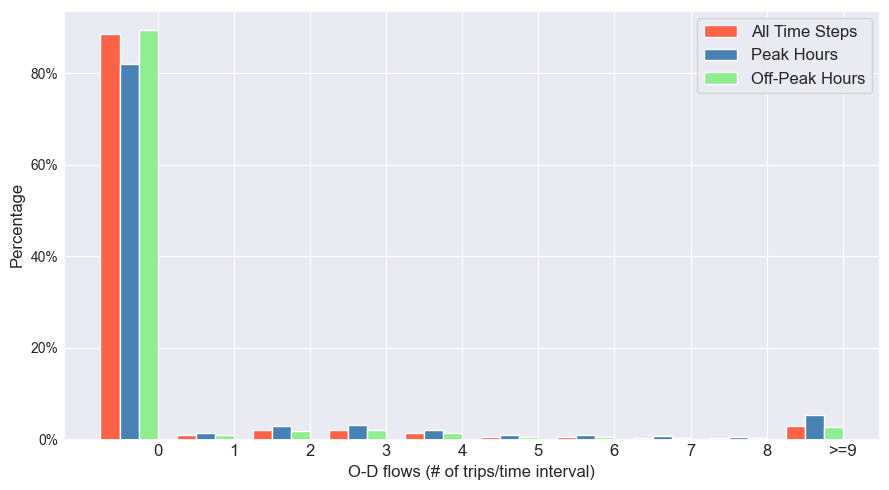

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
# 加载数据
od = np.load('./data/OD_完整批处理_3.17_Final.npy')  # 形状 [T, N, N]，T 为 168（24×7）

# 时间区间划分（周中 7-9、17-19 为高峰，其余为平峰）
all_time = np.arange(168)
peak_time_indices = []
for day in range(5):  # 周一到周五（索引 0-4）
    peak_morning = [day * 24 + 7, day * 24 + 8]   # 7-9 点
    peak_evening = [day * 24 + 17, day * 24 + 18] # 17-19 点
    peak_time_indices.extend(peak_morning)
    peak_time_indices.extend(peak_evening)
peak_time_indices = np.array(peak_time_indices)
off_peak_time_indices = np.setdiff1d(all_time, peak_time_indices)

# 提取并展平三种场景的 OD 数据
od_all_flat = od.reshape(-1, od.shape[1]*od.shape[2]).flatten()
od_peak_flat = od[peak_time_indices].reshape(-1, od.shape[1]*od.shape[2]).flatten()
od_off_peak_flat = od[off_peak_time_indices].reshape(-1, od.shape[1]*od.shape[2]).flatten()


# 统计区间与标签
bins = [0,1,2,3,4,5,6,7,8,9]
labels = ['0','1','2','3','4','5','6','7','8','>=9']

# 计算各区间占比
def calc_percentages(data):
    counts = [np.sum(data==i) for i in range(9)] + [np.sum(data>=9)]
    return [c/len(data)*100 for c in counts]

all_pct = calc_percentages(od_all_flat)
peak_pct = calc_percentages(od_peak_flat)
off_peak_pct = calc_percentages(od_off_peak_flat)


# 绘图配置
plt.figure(figsize=(9,5))  # 保持原图比例
x = np.arange(len(labels))
bar_width = 0.25
colors = ['#FF6347','#4682B4','#90EE90']  # 贴近原图配色
legends = ['All Time Steps','Peak Hours','Off-Peak Hours']

# 绘制柱状图：关键！通过 align='edge' + 偏移实现刻度贴柱子右侧
# 全部时间步柱子：左边缘对齐 x - bar_width，实现视觉上右移
plt.bar(x - bar_width, all_pct, width=bar_width, color=colors[0], label=legends[0], align='edge')
# 高峰期柱子：左边缘对齐 x，自然右移
plt.bar(x, peak_pct, width=bar_width, color=colors[1], label=legends[1], align='edge')
# 平峰期柱子：左边缘对齐 x + bar_width，自然右移
plt.bar(x + bar_width, off_peak_pct, width=bar_width, color=colors[2], label=legends[2], align='edge')


# 坐标轴强化：刻度线向内 + 加粗
ax = plt.gca()
# 刻度线长度 10、宽度 1.5、方向向内
ax.tick_params(axis='both', length=10, width=2, direction='in')
# 坐标轴边框加粗（2 磅）
for spine in ax.spines.values():
    spine.set_linewidth(2)

# 设置刻度位置和标签
ax.set_xticks(x + 2*bar_width)
ax.set_xticklabels(labels, fontsize=12)  # 设置x轴刻度文字大小

# 关键：强制设置y轴为百分比格式（两种方式确保生效）
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))  # 方式1：百分比格式化
plt.ylabel('Percentage', fontsize=18)  # 方式2：标签明确标注%




# 标签与图例（英文）
plt.xlabel('O-D flows (# of trips/time interval)', fontsize=12)
plt.ylabel('Percentage', fontsize=12)
plt.legend(fontsize=12)

plt.tight_layout()
# plt.show()
plt.savefig("./可视化/结果图/OD值稀疏分布图-{formatted_time}.png", format='png', dpi=300, bbox_inches='tight')